In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from models.unet import UNet

In [92]:
EPOCHS = 50
L = 1000
BATCH = 64

device = "cude" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [ ]:
# Loading MNIST dataset
# Convert to tensor and normalize between -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=64, num, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=64, shuffle=False)
    

Min values per image: tensor(-1.)
Max values per image: tensor(1.)
Shape: torch.Size([64, 1, 28, 28])


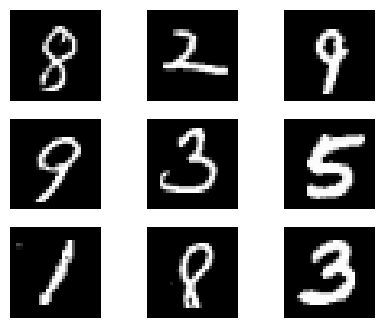

In [94]:
# Load 1 Batch
imgs, _ = next(iter(train_loader))

# Check min-max values to confirm normalization
min_per_img = min(imgs.view(imgs.size(0), -1).min(dim=1).values)
max_per_img = max(imgs.view(imgs.size(0), -1).max(dim=1).values)
print("Min values per image:", min_per_img)
print("Max values per image:", max_per_img)

# Check tensor dimensions
print(f"Shape: {imgs.shape}")

# Visualise a 9 x 9 grid of images from training set
plt.figure(figsize=(5, 4))
for _ in range(9):
    plt.subplot(3, 3, _ + 1)
    plt.imshow(imgs[_].permute(1, 2, 0), cmap="gray")
    plt.axis("off")
plt.show() 

In [95]:
def make_beta_schedule(L, type='linear', beta_min=1e-4, beta_max=0.02):
    if type == 'linear':
        return torch.linspace(beta_min, beta_max, L)
    else:
        return torch.linspace(beta_min**0.5, beta_max**0.5, L) ** 2

In [96]:
class DiffusionProcess:
    def __init__(self, L, device="cpu"):
        self.L = L
        self.device = device

        self.betas = make_beta_schedule(L).to(device)

        self.alphas = (1.0 - self.betas).to(device)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0).to(device)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod).to(device)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas).to(device)

        # beta_tilde_i = (1 - alpha_bar_{i-1}) / (1 - alpha_bar_i) * beta_i
        alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0).to(device) # pad with a 0 at the start because for i=0, there is no i-1.

        self.posterior_variance = self.betas * (1.0 - alphas_cumprod_prev) / (1.0 - self.alphas_cumprod).to(device)

        # mu_tilde = (sqrt(alpha_bar_{i-1}) * beta_i / (1 - alpha_bar_i)) * x_0 + (sqrt(alpha_{i}) * (1 - alpha_bar_{i-1}) / (1 - alpha_bar_i)) * x_i
        self.posterior_mean_coef1 = self.betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - self.alphas_cumprod).to(device)
        self.posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod).to(device)
        
    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.L, (batch_size,), device=self.device)

    def q_sample(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)

        sqrt_alpha_bar = self.extract(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        
        return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * eps

    def extract(self, v, t, x_shape):
        """Helper to extract t-index values and reshape for broadcasting"""
        # Pull the values for the specific timesteps in 't'
        out = v.gather(-1, t)
        # Add (1, 1, 1) to the end of the shape
        # len(x_shape) - 1 calculates how many '1s' we need (usually 3 for images)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))
    
    def q_posterior_mean_var(self, x0, xi, t):
        """Computes the mean and variance of the true posterior q(xi-1 | xi, x0)"""
        coef1 = self.extract(self.posterior_mean_coef1, t, xi.shape)
        coef2 = self.extract(self.posterior_mean_coef2, t, xi.shape)
        
        mu_tilde = coef1 * x0 + coef2 * xi
        posterior_var = self.extract(self.posterior_variance, t, xi.shape)
        
        return mu_tilde, posterior_var

    def predict_x0_from_eps(self, xi, t, eps_hat):
        """Predicts x0 from current noisy image and predicted noise"""
        sqrt_recip_alpha_bar = self.extract(torch.sqrt(1.0 / self.alphas_cumprod), t, xi.shape)
        sqrt_eps_coef = self.extract(torch.sqrt(1.0 / self.alphas_cumprod - 1), t, xi.shape)
        
        return sqrt_recip_alpha_bar * xi - sqrt_eps_coef * eps_hat

    def p_mean_from_eps(self, xi, t, eps_hat):
        """Computes the mean of p(xi-1 | xi) using the model's noise prediction (Equation 8)"""
        coef = self.extract(self.betas / self.sqrt_one_minus_alphas_cumprod, t, xi.shape)
        mu = self.extract(self.sqrt_recip_alphas, t, xi.shape) * (xi - coef * eps_hat)
        return mu

    def p_sample_step(self, xi, t, eps_hat):
        """The core reverse step: samples xi-1 given xi and the model's noise prediction"""
        mu = self.p_mean_from_eps(xi, t, eps_hat)

        if (t > 0).all():
            z = torch.randn_like(xi)
            sigma = torch.sqrt(self.extract(self.posterior_variance, t, xi.shape))
            return mu + sigma * z
        else:
            return mu

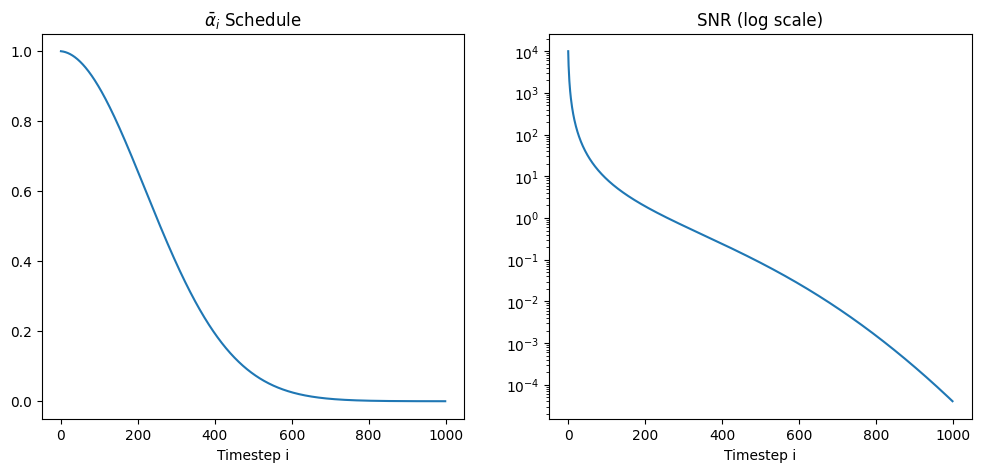

In [97]:
diff = DiffusionProcess(L=1000, device=device)
alphas_bar = diff.alphas_cumprod.to("cpu").numpy()
snr = alphas_bar / (1 - alphas_bar)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas_bar)
plt.title(r"$\bar{\alpha}_i$ Schedule")
plt.xlabel("Timestep i")

plt.subplot(1, 2, 2)
plt.plot(snr)
plt.yscale('log')
plt.title("SNR (log scale)")
plt.xlabel("Timestep i")
plt.show()

In [98]:
x0 = imgs[0:1]
x0 = x0.to(device)
i = torch.tensor([500]).to(device)

samples = []
for _ in range(1000):
    xi = diff.q_sample(x0, i)
    samples.append(xi)

samples = torch.cat(samples, dim=0) # [1000, 1, 28, 28]

emp_mean = samples.mean().item()
emp_var = samples.var().item()

theo_mean = (diff.extract(diff.sqrt_alphas_cumprod, i, x0.shape) * x0).mean().item()
theo_var = (1 - diff.alphas_cumprod[i]).item()

print(f"Empirical Mean: {emp_mean:.4f} | Theoretical: {theo_mean:.4f}")
print(f"Empirical Var:  {emp_var:.4f} | Theoretical: {theo_var:.4f}")

Empirical Mean: -0.2270 | Theoretical: -0.2277
Empirical Var:  0.9425 | Theoretical: 0.9222


In [99]:
# Check for i >= 2 (index 1 in 0-based indexing)
beta_i = diff.betas[1:]
beta_tilde_i = diff.posterior_variance[1:]

print(f"All beta_tilde > 0: {torch.all(beta_tilde_i > 0).item()}")
print(f"All beta_tilde < beta: {torch.all(beta_tilde_i < beta_i).item()}")

All beta_tilde > 0: True
All beta_tilde < beta: True


In [101]:
x0 = imgs[0:1].to(device)
t = torch.tensor([50]).to(device)
eps = torch.randn_like(x0, device=device)
xi = diff.q_sample(x0, t, eps)

# theoretical posterior mean
mu_tilde, _ = diff.q_posterior_mean_var(x0, xi, t)

# predicted mean from perfect epsilon
mu_p = diff.p_mean_from_eps(xi, t, eps)

diff_val = torch.abs(mu_tilde - mu_p).max().item()
print(f"Max difference between posterior mean and p_mean: {diff_val:.6f}")

Max difference between posterior mean and p_mean: 0.000001


In [102]:
model = UNet()
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

In [107]:
def periodic_sample_grids(model, count, device):
    model.eval()
    model.to(device)
    with torch.no_grad():
        xi = torch.randn((count, 1, 28, 28), device=device)
        for i in reversed(range(L)):
            t_tensor = torch.full((count,), i, device=device, dtype=torch.long)
            eps_hat = model(xi, t_tensor)
            xi = diff.p_sample_step(xi, t_tensor, eps_hat)
    model.train()
    plt.figure(figsize=(5, 4))
    for _ in range(count):
        plt.subplot(3, 3, _ + 1)
        plt.imshow(xi[_].to("cpu").permute(1, 2, 0), cmap="gray")
        plt.axis("off")
    plt.show() 

Epoch 1 Loss: 0.0354: 100%|██████████| 938/938 [00:46<00:00, 20.00it/s]


Gradient Norm: 0.3044


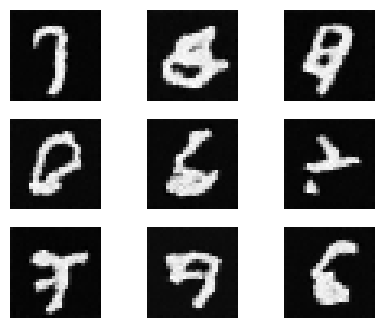

Epoch 6 Loss: 0.0238: 100%|██████████| 938/938 [00:46<00:00, 19.96it/s]


Gradient Norm: 0.1106


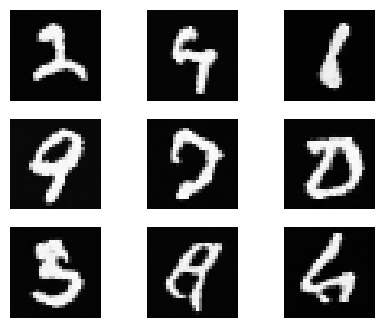

Epoch 9 Loss: 0.0292:  67%|██████▋   | 632/938 [00:31<00:15, 19.99it/s]


KeyboardInterrupt: 

In [108]:
losses = []
model.to(device)
for i in range(EPOCHS):
    pbar = tqdm(train_loader)
    for img, _ in pbar:
        img = img.to(device)
        start = diff.sample_timesteps(img.shape[0]).to(device)
        eps = torch.randn_like(img, device=device)
        xi = diff.q_sample(img, start, eps)

        eps_hat = model(xi, start)

        loss = criterion(eps_hat, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        pbar.set_description(f"Epoch {i+1} Loss: {loss.item():.4f}")

    if i % 5 == 0:
        total_norm = sum(p.grad.detach().data.norm(2).item() ** 2 for p in model.parameters() if p.grad is not None) ** 0.5
        print(f"Gradient Norm: {total_norm:.4f}")
        periodic_sample_grids(model, 9, device)

        